In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

# Load saved model and data
model = joblib.load("../models/best_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

df = pd.read_csv("../data/diabetes_clean.csv")
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("Model and data loaded!")
print("Features:", feature_names)

Model and data loaded!
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [2]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["Outcome"])
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (614, 8)
Test size: (154, 8)


In [3]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (154, 8)


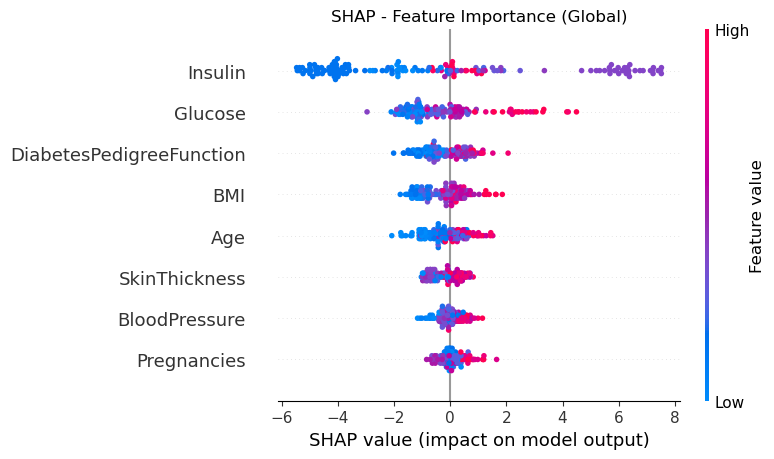

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP - Feature Importance (Global)")
plt.tight_layout()
plt.show()

In [5]:
# Pick one diabetic patient
import numpy as np

diabetic_idx = np.where(y_test.values == 1)[0][0]
sample = X_test.iloc[[diabetic_idx]]

print("Patient details:")
print(sample.T)
print(f"\nActual: Diabetes")
print(f"Predicted probability: {model.predict_proba(sample)[0,1]:.1%}")

Patient details:
                              631
Pregnancies                 7.000
Glucose                   114.000
BloodPressure              64.000
SkinThickness              32.000
Insulin                   169.500
BMI                        27.400
DiabetesPedigreeFunction    0.732
Age                        34.000

Actual: Diabetes
Predicted probability: 99.7%


In [7]:
import os
os.makedirs("../reports", exist_ok=True)
print("Reports folder created!")

Reports folder created!


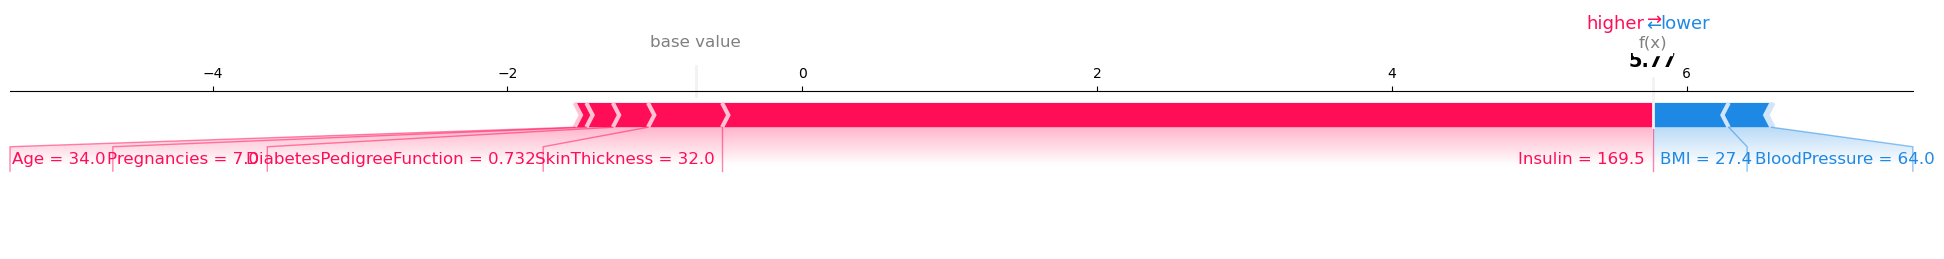

In [9]:
shap.force_plot(
    explainer.expected_value,
    shap_values[diabetic_idx],
    sample,
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.savefig("../reports/shap_force_plot.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
#Ethics Section

print("""
ETHICS & BIAS CONSIDERATIONS
==============================

1. POPULATION BIAS:
   - Dataset contains only female patients of Pima Indian heritage, age 21+
   - Model should NOT be used for male patients or other populations

2. MISSING DATA BIAS:
   - Zeros were used as missing values (Glucose, BMI, etc.)
   - Imputed using median - may bias toward average patients

3. BLACK BOX PROBLEM (SOLVED):
   - SHAP used to explain every prediction
   - Clinicians can now audit why a prediction was made

4. DECISION THRESHOLD:
   - Default 0.5 threshold used
   - Real medical tool needs clinical validation of threshold

5. NOT A DIAGNOSIS:
   - This model estimates RISK only
   - Final diagnosis must be made by a qualified doctor
""")


ETHICS & BIAS CONSIDERATIONS

1. POPULATION BIAS:
   - Dataset contains only female patients of Pima Indian heritage, age 21+
   - Model should NOT be used for male patients or other populations

2. MISSING DATA BIAS:
   - Zeros were used as missing values (Glucose, BMI, etc.)
   - Imputed using median - may bias toward average patients

3. BLACK BOX PROBLEM (SOLVED):
   - SHAP used to explain every prediction
   - Clinicians can now audit why a prediction was made

4. DECISION THRESHOLD:
   - Default 0.5 threshold used
   - Real medical tool needs clinical validation of threshold

5. NOT A DIAGNOSIS:
   - This model estimates RISK only
   - Final diagnosis must be made by a qualified doctor



In [2]:
import os
print(os.path.abspath("../"))


C:\Users\mailm\Documents\medilens-ai
